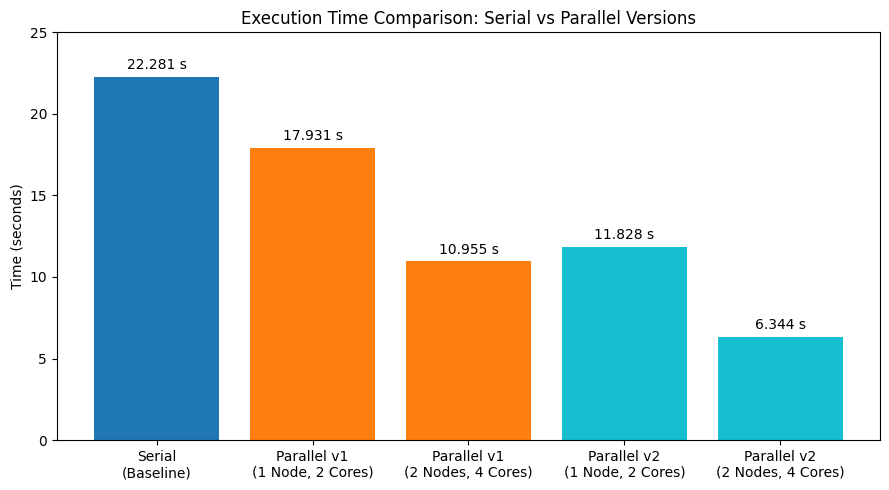

In [ ]:
import matplotlib.pyplot as plt

# Data
labels = [
    "Serial\n(Baseline)",
    "Parallel v1\n(1 Node, 2 Cores)",
    "Parallel v1\n(2 Nodes, 4 Cores)",
    "Parallel v2\n(1 Node, 2 Cores)",
    "Parallel v2\n(2 Nodes, 4 Cores)"
]
times = [22.281, 17.931, 10.955, 11.828, 6.344]

# Colors
colors = ['#1f77b4', '#ff7f0e', '#ff7f0e', '#17becf', '#17becf']

# Plot
plt.figure(figsize=(9, 5))
bars = plt.bar(labels, times, color=colors)

# Add text labels on top of bars
for bar, time in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{time:.3f} s", ha='center', va='bottom', fontsize=10)

plt.ylabel("Time (seconds)")
plt.title("Execution Time Comparison: Serial vs Parallel Versions")
plt.ylim(0, 25)
plt.tight_layout()
plt.show()


<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2753612744.py:55: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title('Individual Process Computation Time for $\pi$ Calculation', fontsize=16)


Grouped bar chart saved as 'pi_process_rank_times_parallel_only.png'


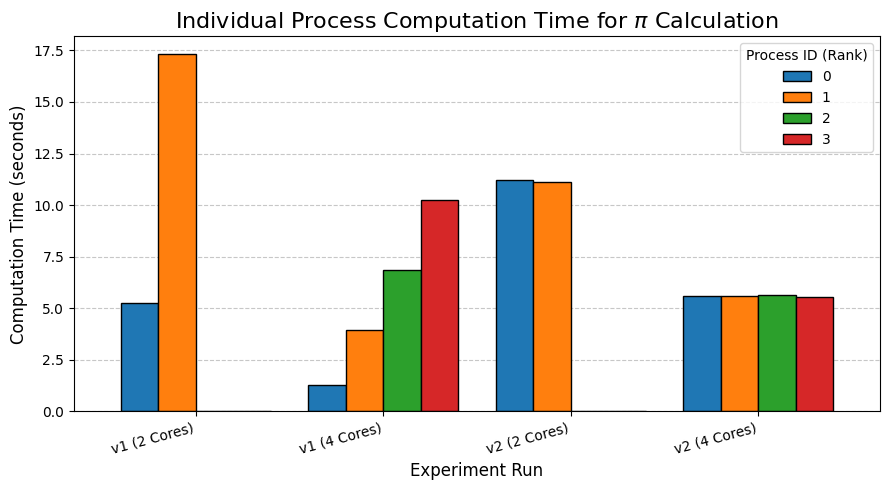

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Collect all the data from your outputs.
# This is the data you provided.
data = [
    # pi_parallel_v1_c1.out (2 processes, unbalanced)
    {'run': 'v1 (2 Cores)', 'process_id': 0, 'time': 5.2407},
    {'run': 'v1 (2 Cores)', 'process_id': 1, 'time': 17.3174},

    # pi_parallel_v1_c2.out (4 processes, unbalanced)
    {'run': 'v1 (4 Cores)', 'process_id': 0, 'time': 1.2946},
    {'run': 'v1 (4 Cores)', 'process_id': 1, 'time': 3.9517},
    {'run': 'v1 (4 Cores)', 'process_id': 2, 'time': 6.8650},
    {'run': 'v1 (4 Cores)', 'process_id': 3, 'time': 10.2235},

    # pi_parallel_v2_c1.out (2 processes, balanced)
    {'run': 'v2 (2 Cores)', 'process_id': 0, 'time': 11.2248},
    {'run': 'v2 (2 Cores)', 'process_id': 1, 'time': 11.1288},

    # pi_parallel_v2_c2.out (4 processes, balanced)
    {'run': 'v2 (4 Cores)', 'process_id': 0, 'time': 5.5933},
    {'run': 'v2 (4 Cores)', 'process_id': 1, 'time': 5.6092},
    {'run': 'v2 (4 Cores)', 'process_id': 2, 'time': 5.6313},
    {'run': 'v2 (4 Cores)', 'process_id': 3, 'time': 5.5522}
]

# 2. Create a Pandas DataFrame
df = pd.DataFrame(data)

# 3. Pivot the DataFrame to prepare it for a grouped bar chart.
# This puts 'run' on the x-axis and 'process_id' as the groups.
df_pivot = df.pivot(index='run', columns='process_id', values='time')

# 4. Define a logical order for the runs (not alphabetical)
run_order = [
    'v1 (2 Cores)',
    'v1 (4 Cores)',
    'v2 (2 Cores)',
    'v2 (4 Cores)'
]
# Apply the logical order
df_pivot = df_pivot.reindex(run_order)

# 5. Create the grouped bar plot
# We use pandas' built-in plotting which uses matplotlib
ax = df_pivot.plot(
    kind='bar',
    figsize=(9, 5),  # Widen the figure to fit the groups
    width=0.8,         # Adjust bar width
    edgecolor='black'  # Add edges to bars for clarity
)

# 6. Customize the plot for clarity
ax.set_title('Individual Process Computation Time for $\pi$ Calculation', fontsize=16)
ax.set_ylabel('Computation Time (seconds)', fontsize=12)
ax.set_xlabel('Experiment Run', fontsize=12)

# Customize the x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=10)

# Add a horizontal grid for easier reading of values
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Put grid behind bars

# Customize the legend
ax.legend(title='Process ID (Rank)', loc='upper right')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# 7. Save the plot to a file
# You can change the filename if you like
plt.savefig('pi_process_rank_times_parallel_only.png')

print("Grouped bar chart saved as 'pi_process_rank_times_parallel_only.png'")

Comparison plot saved as 'fl_vs_serial_comparison.png'

Data used for plotting:
| Run          | Scaling         |   Time (s) |   Accuracy |
|:-------------|:----------------|-----------:|-----------:|
| Serial       | With Scaling    |    13.4290 |     0.6459 |
| Serial       | Without Scaling |    12.6770 |     0.6585 |
| FL S1 (1x10) | With Scaling    |    20.6180 |     0.5612 |
| FL S1 (1x10) | Without Scaling |    20.2120 |     0.6244 |
| FL S2 (10x1) | With Scaling    |    17.9780 |     0.5611 |
| FL S2 (10x1) | Without Scaling |    17.8090 |     0.6307 |
| FL Malicious | With Scaling    |    18.1460 |     0.5017 |
| FL Malicious | Without Scaling |    17.9060 |     0.5822 |


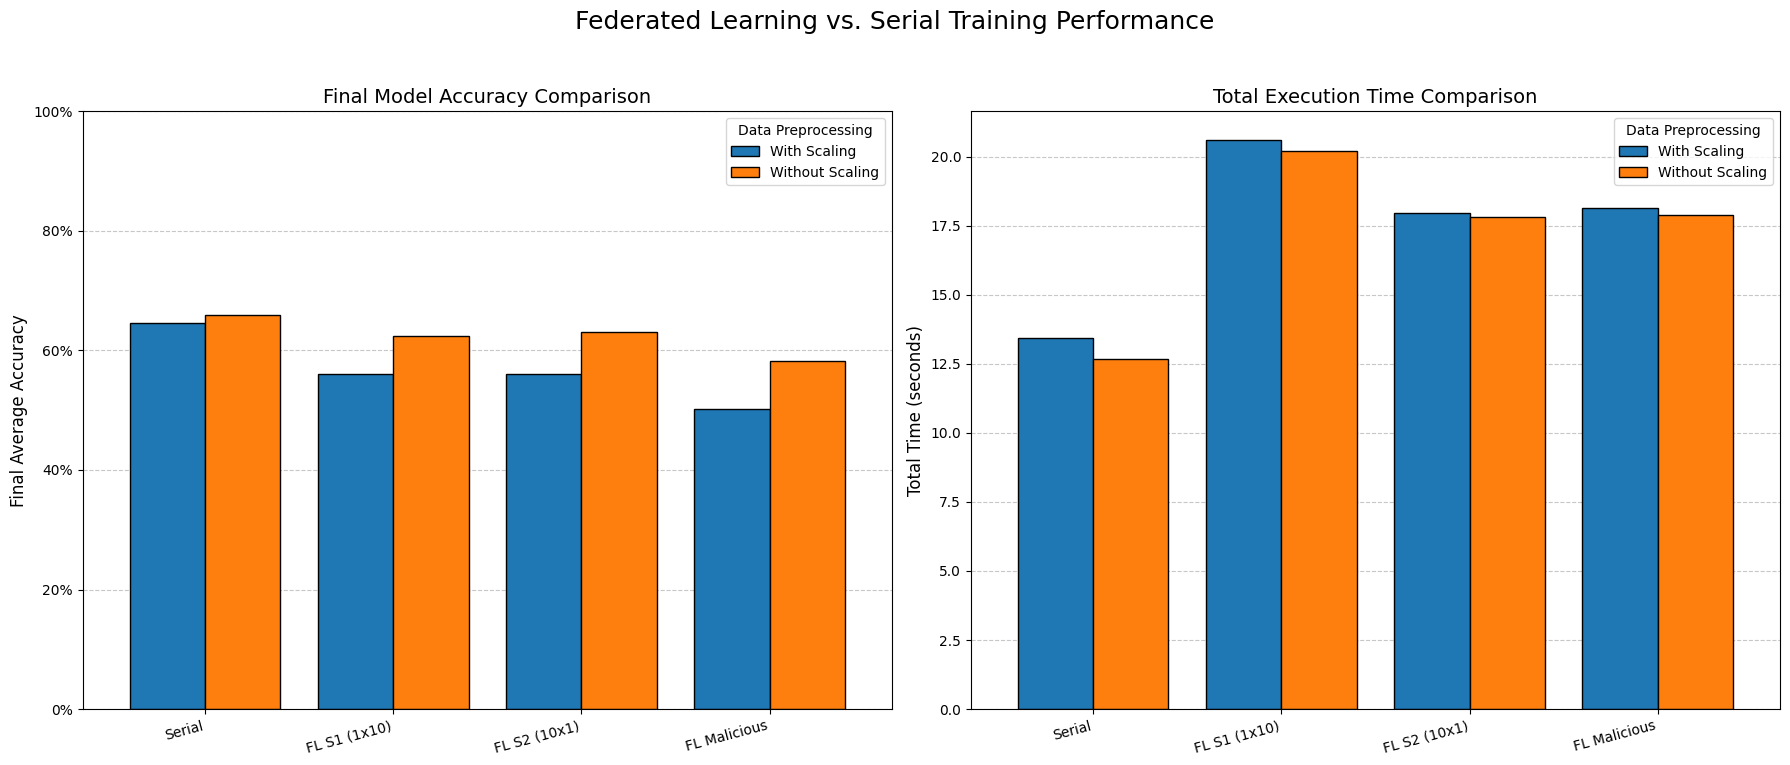

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# 1. Extracted data from all your outputs
# We capture the run type, scaling, final time, and final accuracy.

data = [
    # --- Serial Runs ---
    {'Run': 'Serial', 'Scaling': 'With Scaling',
     'Time (s)': 13.429, 'Accuracy': 0.6459},

    {'Run': 'Serial', 'Scaling': 'Without Scaling',
     'Time (s)': 12.677, 'Accuracy': 0.6585},

    # --- Federated Scenario 1 (1 Round, 10 Epochs) ---
    {'Run': 'FL S1 (1x10)', 'Scaling': 'With Scaling',
     'Time (s)': 20.618, 'Accuracy': 0.5612},

    # Note: 'real' time was missing for this run, so we use np.nan
    {'Run': 'FL S1 (1x10)', 'Scaling': 'Without Scaling',
     'Time (s)': 20.212, 'Accuracy': 0.6244},

    # --- Federated Scenario 2 (10 Rounds, 1 Epoch) ---
    {'Run': 'FL S2 (10x1)', 'Scaling': 'With Scaling',
     'Time (s)': 17.978, 'Accuracy': 0.5611},

    {'Run': 'FL S2 (10x1)', 'Scaling': 'Without Scaling',
     'Time (s)': 17.809, 'Accuracy': 0.6307},

    # --- Federated Malicious (10 Rounds, 1 Epoch) ---
    {'Run': 'FL Malicious', 'Scaling': 'With Scaling',
     'Time (s)': 18.146, 'Accuracy': 0.5017},

    {'Run': 'FL Malicious', 'Scaling': 'Without Scaling',
     'Time (s)': 17.906, 'Accuracy': 0.5822},
]

# 2. Create a Pandas DataFrame
df = pd.DataFrame(data)

# 3. Define a logical order for the plots
run_order = ['Serial', 'FL S1 (1x10)', 'FL S2 (10x1)', 'FL Malicious']

# 4. Create the two side-by-side plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
fig.suptitle('Federated Learning vs. Serial Training Performance', fontsize=18)

# --- Plot 1: Final Model Accuracy ---
ax_acc = axes[0]
df_acc_pivot = df.pivot(index='Run', columns='Scaling', values='Accuracy')
# Re-order the runs logically
df_acc_pivot = df_acc_pivot.reindex(run_order)

df_acc_pivot.plot(kind='bar', ax=ax_acc, edgecolor='black', width=0.8,
                  color=['#1f77b4', '#ff7f0e']) # Standard colors

ax_acc.set_title('Final Model Accuracy Comparison', fontsize=14)
ax_acc.set_ylabel('Final Average Accuracy', fontsize=12)
ax_acc.set_xlabel('') # No x-label, it's shared
ax_acc.set_xticklabels(ax_acc.get_xticklabels(), rotation=15, ha='right')
ax_acc.yaxis.grid(True, linestyle='--', alpha=0.7)
ax_acc.set_axisbelow(True)
# Format y-axis as percentage
ax_acc.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_acc.set_ylim(0, 1.0) # Set y-axis from 0% to 100%
ax_acc.legend(title='Data Preprocessing')


# --- Plot 2: Total Execution Time ---
ax_time = axes[1]
df_time_pivot = df.pivot(index='Run', columns='Scaling', values='Time (s)')
# Re-order the runs logically
df_time_pivot = df_time_pivot.reindex(run_order)

df_time_pivot.plot(kind='bar', ax=ax_time, edgecolor='black', width=0.8,
                   color=['#1f77b4', '#ff7f0e'])

ax_time.set_title('Total Execution Time Comparison', fontsize=14)
ax_time.set_ylabel('Total Time (seconds)', fontsize=12)
ax_time.set_xlabel('')
ax_time.set_xticklabels(ax_time.get_xticklabels(), rotation=15, ha='right')
ax_time.yaxis.grid(True, linestyle='--', alpha=0.7)
ax_time.set_axisbelow(True)
ax_time.legend(title='Data Preprocessing')


# 5. Final Touches
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.savefig('fl_vs_serial_comparison.png')

print("Comparison plot saved as 'fl_vs_serial_comparison.png'")

print("\nData used for plotting:")
print(df.to_markdown(index=False, floatfmt=".4f"))

Data used for plotting:
| Task           | Library    |   Time (s) |
|:---------------|:-----------|-----------:|
| Determinant 5k | OpenBLAS   |      2.485 |
| Determinant 5k | Accelerate |      1.174 |
| Determinant 8k | OpenBLAS   |      8.214 |
| Determinant 8k | Accelerate |      4.188 |
| Inverse 5k     | OpenBLAS   |      7.037 |
| Inverse 5k     | Accelerate |      5.473 |
| Inverse 8k     | OpenBLAS   |     25.333 |
| Inverse 8k     | Accelerate |     20.474 |

Grouped bar chart saved as 'blas_performance_comparison.png'


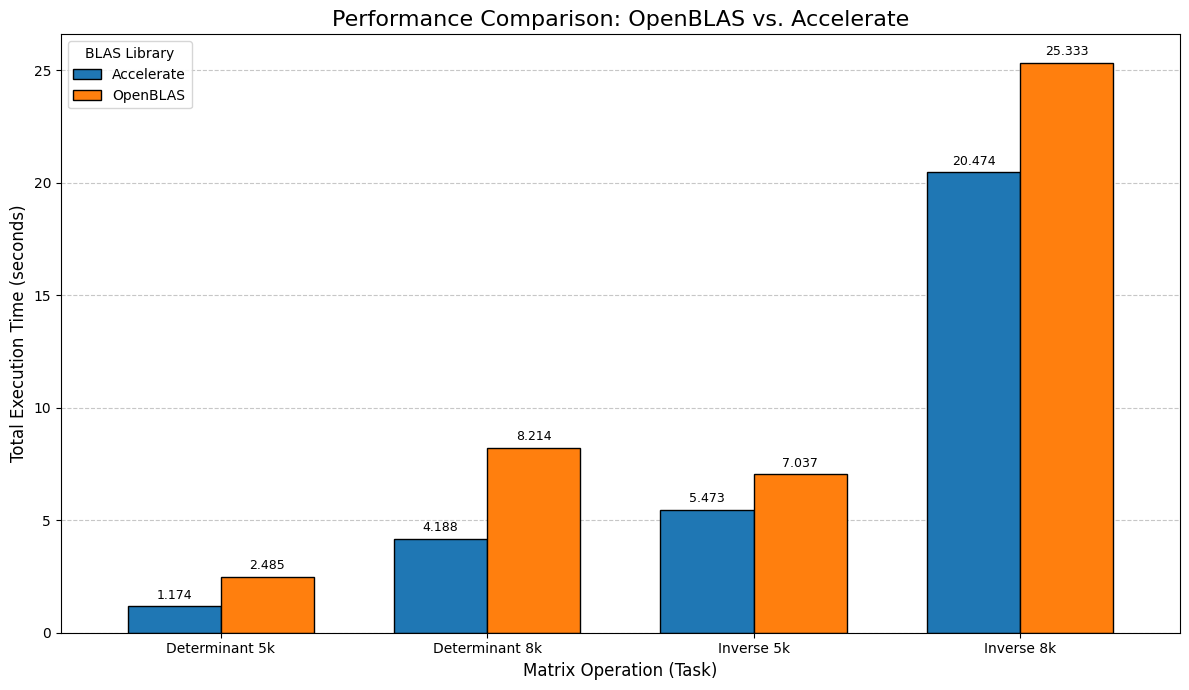

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the data
# We structure this as a list of dictionaries, which is easy to
# convert into a Pandas DataFrame.
data = [
    # Determinant 5k x 5k
    {'Task': 'Determinant 5k', 'Library': 'OpenBLAS', 'Time (s)': 2.485},
    {'Task': 'Determinant 5k', 'Library': 'Accelerate', 'Time (s)': 1.174},

    # Determinant 8k x 8k
    {'Task': 'Determinant 8k', 'Library': 'OpenBLAS', 'Time (s)': 8.214},
    {'Task': 'Determinant 8k', 'Library': 'Accelerate', 'Time (s)': 4.188},

    # Inverse 5k x 5k
    {'Task': 'Inverse 5k', 'Library': 'OpenBLAS', 'Time (s)': 7.037},
    {'Task': 'Inverse 5k', 'Library': 'Accelerate', 'Time (s)': 5.473},

    # Inverse 8k x 8k
    {'Task': 'Inverse 8k', 'Library': 'OpenBLAS', 'Time (s)': 25.333},
    {'Task': 'Inverse 8k', 'Library': 'Accelerate', 'Time (s)': 20.474},
]

# 2. Create the DataFrame
df = pd.DataFrame(data)

# --- THIS IS THE ADDED SECTION ---
print("Data used for plotting:")
print(df.to_markdown(index=False, floatfmt=".3f"))
# --- END OF ADDED SECTION ---

# 3. Pivot the DataFrame to get 'Library' as columns and 'Task' as the index
# This is the standard format for creating a grouped bar chart.
df_pivot = df.pivot(index='Task', columns='Library', values='Time (s)')

# 4. Define a logical order for the tasks on the x-axis
task_order = ['Determinant 5k', 'Determinant 8k', 'Inverse 5k', 'Inverse 8k']
df_pivot = df_pivot.reindex(task_order)

# 5. Create the plot
ax = df_pivot.plot(
    kind='bar',
    figsize=(12, 7),  # Set the figure size
    width=0.7,         # Adjust the width of the bar groups
    edgecolor='black'  # Add a black edge to bars for clarity
)

# 6. Customize the plot
ax.set_title('Performance Comparison: OpenBLAS vs. Accelerate', fontsize=16)
ax.set_ylabel('Total Execution Time (seconds)', fontsize=12)
ax.set_xlabel('Matrix Operation (Task)', fontsize=12)

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

# Add a grid for easier value reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Send gridlines behind the bars

# Add text labels on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position (center)
        height + 0.2,                       # Y position (just above)
        f'{height:.3f}',                    # The text (3 decimal places)
        ha='center',                        # Horizontal alignment
        va='bottom',                        # Vertical alignment
        fontsize=9
    )

# Adjust legend location
ax.legend(title='BLAS Library', loc='upper left')

# Adjust layout
plt.tight_layout()

# 7. Save the plot to a file
plt.savefig('blas_performance_comparison.png')

print("\nGrouped bar chart saved as 'blas_performance_comparison.png'")

Data used for plotting:
| Experiment      | Rank   |   Accuracy |   Time (s) |
|:----------------|:-------|-----------:|-----------:|
| Without Scaling | Rank 1 |     0.6949 |     2.7364 |
| Without Scaling | Rank 2 |     0.4716 |     0.2465 |
| Without Scaling | Rank 3 |     0.5800 |     0.2506 |
| With Scaling    | Rank 1 |     0.9529 |     2.8680 |
| With Scaling    | Rank 2 |     0.0514 |     0.3063 |
| With Scaling    | Rank 3 |     0.5008 |     0.3166 |


Comparison plot saved as 'fl_scaling_comparison.png'


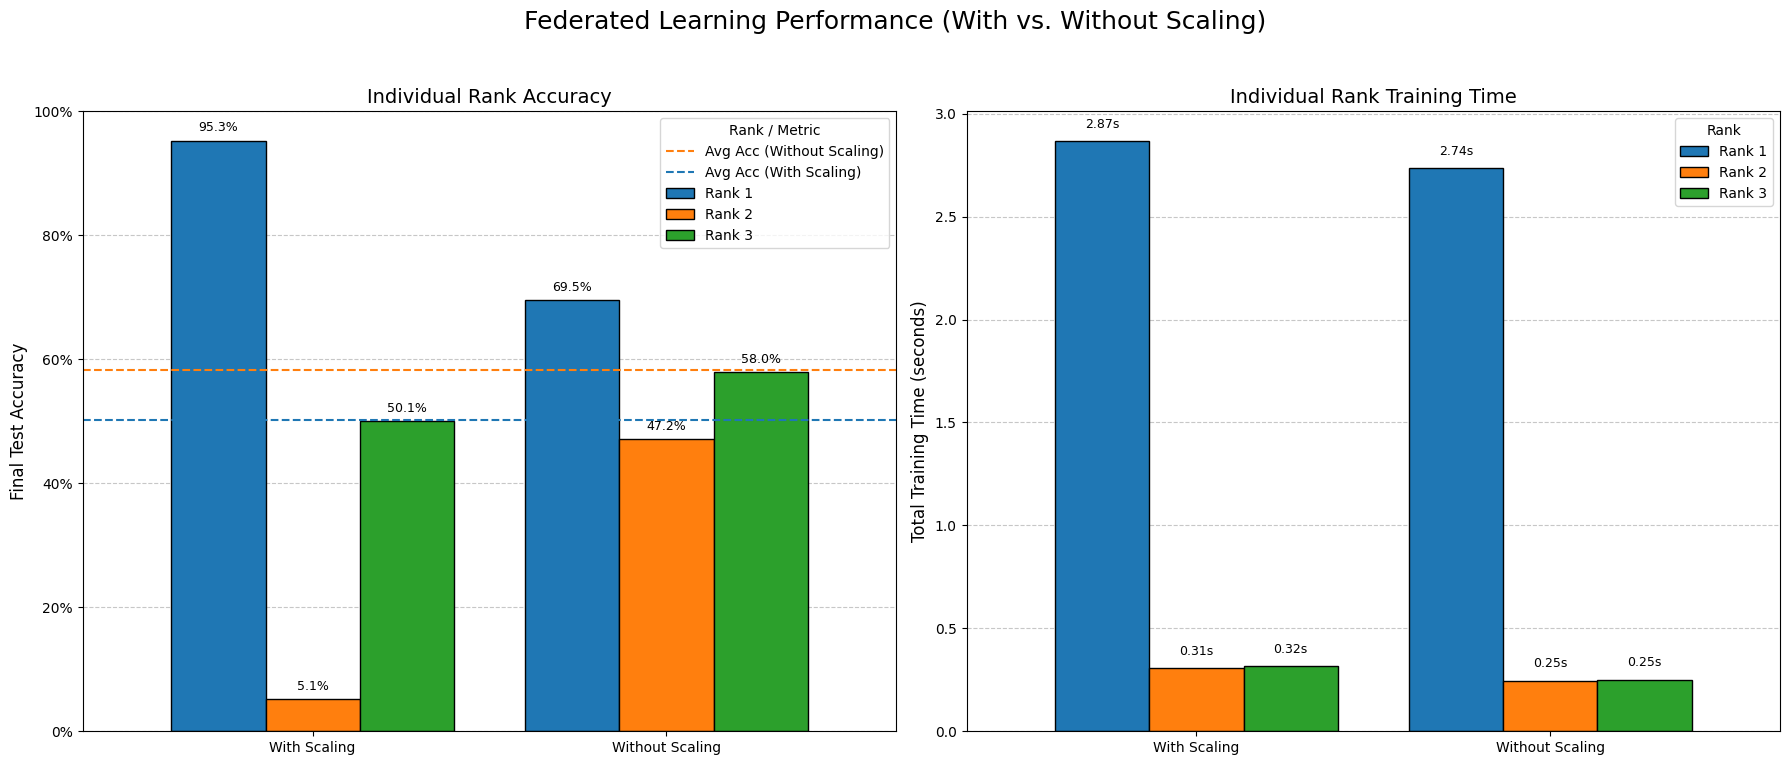

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# 1. Extracted data from the two outputs
data = [
    # --- Run 1: "Without Scaling" ---
    # (Final Avg Acc: 0.5822)
    {'Experiment': 'Without Scaling', 'Rank': 'Rank 1',
     'Accuracy': 0.6949, 'Time (s)': 2.7364},
    {'Experiment': 'Without Scaling', 'Rank': 'Rank 2',
     'Accuracy': 0.4716, 'Time (s)': 0.2465},
    {'Experiment': 'Without Scaling', 'Rank': 'Rank 3',
     'Accuracy': 0.5800, 'Time (s)': 0.2506},

    # --- Run 2: "With Scaling" ---
    # (Final Avg Acc: 0.5017)
    {'Experiment': 'With Scaling', 'Rank': 'Rank 1',
     'Accuracy': 0.9529, 'Time (s)': 2.8680},
    {'Experiment': 'With Scaling', 'Rank': 'Rank 2',
     'Accuracy': 0.0514, 'Time (s)': 0.3063},
    {'Experiment': 'With Scaling', 'Rank': 'Rank 3',
     'Accuracy': 0.5008, 'Time (s)': 0.3166},
]

# 2. Create a Pandas DataFrame
df = pd.DataFrame(data)

# --- ADDED: Print the data table ---
print("Data used for plotting:")
print(df.to_markdown(index=False, floatfmt=".4f"))
print("\n") # Add a newline
# ------------------------------------

# 3. Create the two side-by-side plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
fig.suptitle('Federated Learning Performance (With vs. Without Scaling)',
             fontsize=18)

# Define the order for ranks
rank_order = ['Rank 1', 'Rank 2', 'Rank 3']

# --- Plot 1: Final Model Accuracy ---
ax_acc = axes[0]
df_acc_pivot = df.pivot(index='Experiment', columns='Rank', values='Accuracy')
# Re-order the columns logically
df_acc_pivot = df_acc_pivot[rank_order]

df_acc_pivot.plot(kind='bar', ax=ax_acc, edgecolor='black', width=0.8)

ax_acc.set_title('Individual Rank Accuracy', fontsize=14)
ax_acc.set_ylabel('Final Test Accuracy', fontsize=12)
ax_acc.set_xlabel('')
ax_acc.set_xticklabels(ax_acc.get_xticklabels(), rotation=0)
ax_acc.yaxis.grid(True, linestyle='--', alpha=0.7)
ax_acc.set_axisbelow(True)
ax_acc.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_acc.set_ylim(0, 1.0) # Set y-axis from 0% to 100%

# Add horizontal lines for the "final average accuracy"
ax_acc.axhline(0.5822, color='C1', linestyle='--',
               label='Avg Acc (Without Scaling)')
ax_acc.axhline(0.5017, color='C0', linestyle='--',
               label='Avg Acc (With Scaling)')
ax_acc.legend(title='Rank / Metric', loc='upper right')

# Add text labels (percentages) to each bar
for bar in ax_acc.patches:
    height = bar.get_height()
    label_text = f'{height:.1%}'
    ax_acc.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
                label_text, ha='center', va='bottom', fontsize=9)


# --- Plot 2: Total Execution Time ---
ax_time = axes[1]
df_time_pivot = df.pivot(index='Experiment', columns='Rank', values='Time (s)')
# Re-order the columns logically
df_time_pivot = df_time_pivot[rank_order]

df_time_pivot.plot(kind='bar', ax=ax_time, edgecolor='black', width=0.8)

ax_time.set_title('Individual Rank Training Time', fontsize=14)
ax_time.set_ylabel('Total Training Time (seconds)', fontsize=12)
ax_time.set_xlabel('')
ax_time.set_xticklabels(ax_time.get_xticklabels(), rotation=0)
ax_time.yaxis.grid(True, linestyle='--', alpha=0.7)
ax_time.set_axisbelow(True)
ax_time.legend(title='Rank', loc='upper right')

# Add text labels (seconds) to each bar
for bar in ax_time.patches:
    height = bar.get_height()
    label_text = f'{height:.2f}s'
    ax_time.text(bar.get_x() + bar.get_width() / 2, height + 0.05,
                 label_text, ha='center', va='bottom', fontsize=9)


# 5. Final Touches
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.savefig('fl_scaling_comparison.png')

print("Comparison plot saved as 'fl_scaling_comparison.png'")